
# Transfer Learning & Fine-Tuning BERT

*The domain capstone: how a model that has never seen your labeled data can
still outperform a from-scratch classifier, by first learning language
itself from unlabeled text at massive scale, then being lightly retrained
on your specific task.*

---

## 1. Intro: you don't have to start from zero

Imagine you're hiring for a job that requires reading comprehension in
English. You have two candidates:

- **Candidate A** has never seen written English before. You'll teach them
  the alphabet, grammar, vocabulary, idioms, *and* the actual job — all
  from your 500-example training packet.
- **Candidate B** has already read most of the internet. They know grammar,
  vocabulary, common-sense associations, and how words shift meaning with
  context. You just need to show them your 500 examples so they pick up
  the *one new thing*: what your specific job actually requires.

Candidate B will do dramatically better with the same 500 examples, for an
obvious reason: almost all of the "work" of understanding English was
already done before you ever met them. This is **transfer learning**: take
a model that has already learned a general skill from a huge amount of
data, then **fine-tune** it — continue training it, briefly and gently — on
your smaller, specific task.

In NLP, "Candidate B" is a model like **BERT** (Bidirectional Encoder
Representations from Transformers; Devlin et al., 2019). BERT is
**pretrained** on hundreds of millions of words of unlabeled text (no
human ever labeled any of it) using a self-supervised objective that forces
it to learn grammar, word meaning, and context — for free, just from raw
text. You then **fine-tune** that pretrained model on your actual labeled
task — here, sentiment classification — usually with only a small labeled
dataset and a few passes over it.

This tutorial is this NLP domain's capstone, and it deliberately closes the
loop on everything the rest of the domain built:

- **Bag-of-words / TF-IDF** (the domain's `bag-of-words-and-tfidf`
  tutorial) represents text as sparse word-count vectors with zero notion
  of word order or meaning — fast, interpretable, and a genuinely strong
  baseline, which we'll measure honestly against BERT below.
- **Static word embeddings** (the domain's `word-embeddings` tutorial, e.g.
  word2vec/GloVe) gave every word a single fixed vector — a real step up
  from bag-of-words, but `"bank"` gets the same vector whether it means a
  riverbank or a financial institution.
- **The Transformer's self-attention mechanism** (the domain's
  `transformer-self-attention` tutorial) let every token's representation
  depend on *every other token in the sequence*, finally making
  context-dependent word meaning possible.
- **BERT** takes that Transformer architecture, pretrains it at scale with
  a clever self-supervised objective, and hands you a model that already
  understands language before you write a single line of task-specific
  training code. Fine-tuning it is how nearly all production text
  classification is actually built today.

By the end of this tutorial you'll be able to explain precisely what BERT's
pretraining objective is, why it makes BERT *bidirectional* in a way
GPT-style models are not, how fine-tuning for classification actually
works mechanically, and — critically — you'll have **real, measured
numbers** comparing a classical baseline, an untrained/zero-shot BERT head,
and a genuinely fine-tuned BERT on the same real dataset, so you see
exactly when the extra machinery pays off (and when it doesn't).



## 2. The idea, intuitively

Before any theory, let's just *see* a pretrained BERT-family model do
something a from-scratch model couldn't do without a lot of labeled data:
read a sentence it has never seen and get its sentiment right, using a
model that was already fine-tuned by Hugging Face on this exact kind of
task.


In [1]:

from transformers import pipeline

# A model already fine-tuned on SST-2-style sentiment data.
sentiment = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
)

examples = [
    "This movie was a genuine masterpiece, I was glued to my seat.",
    "I want my two hours back. Painfully boring from start to finish.",
    "It's fine. Not great, not terrible, just fine.",
]

for text in examples:
    result = sentiment(text)[0]
    print(f"{result['label']:>8}  ({result['score']:.3f})  {text}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

POSITIVE  (1.000)  This movie was a genuine masterpiece, I was glued to my seat.
NEGATIVE  (1.000)  I want my two hours back. Painfully boring from start to finish.
POSITIVE  (1.000)  It's fine. Not great, not terrible, just fine.



Notice the model gets the first two right with high confidence, and is
visibly less confident on the deliberately ambiguous third sentence — a
reasonable thing for a model that actually "understands" the text to do.
This particular model was **already fine-tuned** on SST-2 by its authors;
later in this tutorial we build and fine-tune our own from a general
`distilbert-base-uncased` checkpoint, so you see every step of the process
rather than only the finished product.

**The core idea, in one sentence:** BERT spends a huge amount of compute
*once*, learning general language structure from unlabeled text
(**pretraining**); you then spend a tiny amount of compute *per task*,
nudging that general knowledge toward your specific labeled problem
(**fine-tuning**). The expensive step is shared across every task anyone
ever fine-tunes BERT for; only the cheap step is yours to pay.

Why does this work better than training a classifier from scratch on a
small labeled dataset? A from-scratch model has to learn *both* "what
English words and grammar mean" *and* "what distinguishes positive from
negative sentiment" from the same 500 examples. A fine-tuned BERT model
only has to learn the second thing — it already knows the first, learned
from data thousands of times larger than any labeled dataset you're likely
to have.



## 3. Going deeper: the formal definition

### 3.1 Pretraining objective: masked language modeling (MLM)

Recall from the `transformer-self-attention` tutorial that a Transformer
**encoder** layer computes, for every token, an attention-weighted mixture
of *every other token's* representation — nothing in the encoder's
architecture restricts a token to only look left or only look right. BERT
*is* a stack of Transformer encoder layers. The question is: what training
objective actually makes use of that unrestricted, bidirectional access?

You cannot train a bidirectional model with the standard "predict the next
word" **causal language modeling** objective used by GPT-style models,
because if position $i$ can already see position $i+1$ while predicting
position $i+1$, the task is trivial (the answer is already visible as
input) — GPT-style models solve this by **masking future tokens out of
attention entirely** (causal/left-to-right attention), which is exactly
what forces them to be unidirectional.

BERT instead uses **masked language modeling (MLM)**: during pretraining,
a random 15% of input tokens are replaced with a special `[MASK]` token
(with some of that 15% instead replaced by a random token or left
unchanged, to reduce train/inference mismatch), and the model is trained to
predict the *original* token at each masked position, using the full,
unmasked context on **both sides**. Formally, for a sequence
$x_1, \dots, x_n$ with masked positions $M \subset \{1,\dots,n\}$, the
training objective is to minimize

$$
\mathcal{L}_{\text{MLM}} = -\sum_{i \in M} \log P\big(x_i \mid x_{1:n}
\setminus x_M\big)
$$

i.e. maximize the probability of the true token at each masked position
*given every other token in the sequence, left and right*. Because the
objective is "fill in the blank using surrounding context," rather than
"predict the next token given only the past," there is no reason to hide
right-context from the model — which is precisely why BERT's self-attention
is left completely **unmasked** (every position attends to every position),
in contrast to the causal attention mask used by GPT-style decoders. This
is the exact, precise sense in which BERT is **bidirectional**: not a
vague marketing term, but a direct architectural consequence of its
pretraining objective allowing (indeed requiring) attention in both
directions.

BERT's original pretraining also included a second objective, **next
sentence prediction (NSP)**: given two text segments A and B, predict
whether B is the actual sentence that followed A in the source corpus, or
a random unrelated segment — intended to teach sentence-pair relationships
useful for tasks like question answering. NSP is included here for
completeness since it's part of BERT's original paper, but later work
(e.g. RoBERTa, Liu et al. 2019) found NSP contributes little and often
drop it; MLM is the objective doing essentially all of the representational
work.

### 3.2 Fine-tuning for classification

Every token BERT processes gets its own contextual vector, but text
classification needs a single prediction for the *whole* input. BERT's
pretraining prepends a special `[CLS]` ("classification") token to every
input sequence specifically so it has a designated slot to aggregate
whole-sequence information. Fine-tuning for classification, precisely:

1. Tokenize the input and prepend `[CLS]`: `[CLS] this movie was great [SEP]`.
2. Run the full sequence through BERT's Transformer encoder stack, exactly
   as in pretraining.
3. Take the final hidden state at the `[CLS]` position — call it
   $h_{\text{CLS}} \in \mathbb{R}^d$ ($d = 768$ for base-size BERT models,
   $d = 768$ for DistilBERT too since it keeps BERT's hidden size while
   halving the layer count) — and feed it through a small, newly-added
   **linear classification head**: $\hat{y} = \text{softmax}(W
   h_{\text{CLS}} + b)$, where $W \in \mathbb{R}^{k \times d}$ and
   $b \in \mathbb{R}^k$ are randomly initialized (they didn't exist during
   pretraining — there's no reason pretraining would need a sentiment head)
   and $k$ is the number of classes (2, for binary sentiment).
4. Train **every** parameter — both BERT's pretrained encoder weights and
   the new head's weights — jointly, via ordinary gradient descent on the
   task's cross-entropy loss between $\hat{y}$ and the true label.

### 3.3 Why the fine-tuning learning rate must be small: catastrophic forgetting

Step 4 above says "train every parameter," which raises an obvious risk:
BERT's encoder weights already encode a huge amount of useful general
language knowledge, learned from far more data than your fine-tuning set
will ever contain. If you update those weights with the same large
learning rate you'd use training a model from scratch, large gradient
steps can overwrite that pretrained structure faster than the small
fine-tuning dataset can meaningfully replace it — the model **overfits to
its small task dataset while destroying the general knowledge that made it
useful in the first place**. This failure mode has a name: **catastrophic
forgetting**.

The practical fix, used throughout the field and in this tutorial's
implementation, is to fine-tune with a **learning rate roughly 10–100x
smaller** than a from-scratch training run would use (typically
$1\times10^{-5}$ to $5\times10^{-5}$ for BERT-family models, versus
$1\times10^{-3}$ or higher when training a randomly-initialized model), and
for only a **few epochs** (1–4, not dozens). This keeps each gradient step
small enough to nudge the pretrained representations toward the new task
without wiping them out — you're *adapting* general knowledge, not
overwriting it.



## 4. Visuals: the pretrain -> fine-tune pipeline

Before touching real data, here's the pipeline this tutorial builds,
drawn as a diagram: one expensive pretraining stage shared by everyone,
followed by a cheap, task-specific fine-tuning stage that's ours alone.


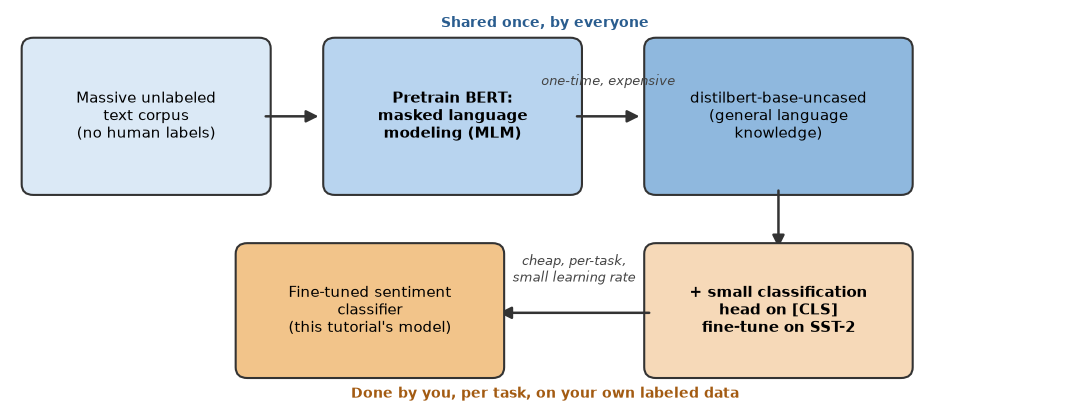

In [2]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.set_xlim(0, 11)
ax.set_ylim(0, 4.2)
ax.axis("off")

def box(x, y, w, h, text, color, fontsize=10.5, weight="normal"):
    b = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.08,rounding_size=0.12",
        linewidth=1.5, edgecolor="#333333", facecolor=color,
    )
    ax.add_patch(b)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
             fontsize=fontsize, weight=weight, wrap=True)

def arrow(x0, y0, x1, y1, label=""):
    a = FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="-|>",
                         mutation_scale=18, linewidth=1.8, color="#333333")
    ax.add_patch(a)
    if label:
        ax.text((x0 + x1) / 2, y0 + 0.35, label, ha="center", fontsize=9,
                 style="italic", color="#444444")

# Stage 1: pretraining (done once, by BERT's authors, shared by everyone)
box(0.2, 2.2, 2.4, 1.6, "Massive unlabeled\ntext corpus\n(no human labels)", "#dbe9f6")
arrow(2.6, 3.0, 3.2, 3.0)
box(3.3, 2.2, 2.5, 1.6, "Pretrain BERT:\nmasked language\nmodeling (MLM)", "#b8d4ef", weight="bold")
arrow(5.8, 3.0, 6.5, 3.0, "one-time, expensive")
box(6.6, 2.2, 2.6, 1.6, "distilbert-base-uncased\n(general language\nknowledge)", "#8fb8de")

# Stage 2: fine-tuning (ours, cheap, per-task)
arrow(7.9, 2.2, 7.9, 1.5)
box(6.6, 0.15, 2.6, 1.35, "+ small classification\nhead on [CLS]\nfine-tune on SST-2", "#f6d9b8", weight="bold")
arrow(6.6, 0.8, 5.0, 0.8, "cheap, per-task,\nsmall learning rate")
box(2.4, 0.15, 2.6, 1.35, "Fine-tuned sentiment\nclassifier\n(this tutorial's model)", "#f2c48a")

ax.text(5.5, 4.0, "Shared once, by everyone", ha="center", fontsize=10, color="#2a5d8f", weight="bold")
ax.text(5.5, -0.15, "Done by you, per task, on your own labeled data", ha="center", fontsize=10, color="#a35b12", weight="bold")

plt.tight_layout()
plt.savefig("pretrain_finetune_pipeline.png", dpi=110, bbox_inches="tight")
plt.show()



The top row (blue) happens **once**, is extremely expensive, and is done
by whoever trained the base model — you never have to repeat it. The
bottom row (orange) is what *you* actually do: attach a small head, and
retrain everything gently on your labeled task. That asymmetry — pay once,
reuse everywhere — is the entire economic case for transfer learning, and
it's why fine-tuning is now the default way production NLP systems are
built rather than training from scratch.



## 5. Implementation: three real, honestly-compared models on real SST-2 data

We now build **three** real classifiers on the same real subset of the
**Stanford Sentiment Treebank v2 (SST-2)** — a binary (positive/negative)
sentence-level movie-review sentiment dataset (Socher et al., 2013),
accessed via Hugging Face `datasets`:

1. **Classical baseline**: TF-IDF features + Logistic Regression — the
   direct callback to this domain's `bag-of-words-and-tfidf` tutorial. No
   pretraining, no neural network, trained entirely from scratch on our
   small labeled subset.
2. **Zero-shot / untrained head**: `distilbert-base-uncased` with a
   **freshly, randomly initialized** classification head — BERT's
   pretrained encoder is there, but the head that turns its representation
   into a positive/negative decision has never seen a single labeled
   example. This demonstrates that a pretrained backbone alone, with no
   fine-tuning, is not a working classifier.
3. **Fine-tuned BERT**: the same `distilbert-base-uncased` model, actually
   fine-tuned (encoder + head, low learning rate, few epochs, per §3.3) on
   our small training subset.

All three are evaluated on the **same held-out subset**, and we report
real accuracy for each — no assumed winner.


In [3]:

import time
import numpy as np
import torch
from datasets import load_dataset

torch.manual_seed(42)
np.random.seed(42)

t_start = time.time()

# Real SST-2 (Socher et al., 2013), via Hugging Face `datasets`.
raw = load_dataset("stanfordnlp/sst2")
print(raw)
print("\nExample:", raw["train"][0])

# Small, CPU-budget-friendly real subsets (fine-tuning BERT on CPU is slow --
# see the Limitations section for why this matters in practice).
N_TRAIN = 400
N_EVAL = 200

train_raw = raw["train"].shuffle(seed=42).select(range(N_TRAIN))
eval_raw = raw["validation"].shuffle(seed=42).select(range(N_EVAL))

train_texts = train_raw["sentence"]
train_labels = train_raw["label"]
eval_texts = eval_raw["sentence"]
eval_labels = eval_raw["label"]

print(f"\nTrain subset: {len(train_texts)} examples | Eval subset: {len(eval_texts)} examples")
print(f"Train label balance: {sum(train_labels)}/{len(train_labels)} positive")
print(f"Eval label balance: {sum(eval_labels)}/{len(eval_labels)} positive")


DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})

Example: {'idx': 0, 'sentence': 'hide new secretions from the parental units ', 'label': 0}

Train subset: 400 examples | Eval subset: 200 examples
Train label balance: 237/400 positive
Eval label balance: 107/200 positive



### 5.1 Baseline: TF-IDF + Logistic Regression

The classical, from-scratch-features approach: represent each sentence as
a sparse TF-IDF vector over its words (no notion of word order or
pretrained knowledge at all), and fit a linear classifier directly on our
small training subset.


In [4]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

t0 = time.time()

vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=1)
X_train_tfidf = vectorizer.fit_transform(train_texts)
X_eval_tfidf = vectorizer.transform(eval_texts)

logreg = LogisticRegression(max_iter=1000, C=1.0)
logreg.fit(X_train_tfidf, train_labels)

tfidf_preds = logreg.predict(X_eval_tfidf)
tfidf_acc = accuracy_score(eval_labels, tfidf_preds)

tfidf_time = time.time() - t0
print(f"TF-IDF + Logistic Regression accuracy: {tfidf_acc:.4f}")
print(f"Training + inference time: {tfidf_time:.2f}s")


TF-IDF + Logistic Regression accuracy: 0.5450
Training + inference time: 0.29s


C:\Users\thoma\cs-ai-tutorials\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(



### 5.2 Zero-shot: pretrained BERT encoder, untrained classification head

Now load `distilbert-base-uncased` as a sequence classifier. Its encoder
weights are pretrained (per §3.1); its classification head (`§3.2`'s $W$,
$b$) is **randomly initialized from scratch**, since a plain
`distilbert-base-uncased` checkpoint was never trained on any
classification task. We evaluate this model **before any fine-tuning** to
show concretely what a pretrained backbone alone gets you.


In [5]:

from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 64

t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
print(f"Load time: {time.time() - t0:.1f}s")
print("(the 'MISSING' params reported above -- classifier/pre_classifier weights --")
print(" are exactly the newly, randomly initialized classification head)")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Load time: 0.8s
(the 'MISSING' params reported above -- classifier/pre_classifier weights --
 are exactly the newly, randomly initialized classification head)


In [6]:

def tokenize_batch(texts, tok, max_length=MAX_LENGTH):
    enc = tok(list(texts), truncation=True, padding=True, max_length=max_length,
               return_tensors="pt")
    return enc

@torch.no_grad()
def evaluate_model(model, tokenizer, texts, labels, batch_size=16, max_length=MAX_LENGTH):
    model.eval()
    all_preds = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        enc = tokenize_batch(batch_texts, tokenizer, max_length)
        out = model(**enc)
        preds = torch.argmax(out.logits, dim=-1).tolist()
        all_preds.extend(preds)
    return accuracy_score(labels, all_preds), all_preds

t0 = time.time()
zero_shot_acc, zero_shot_preds = evaluate_model(model, tokenizer, eval_texts, eval_labels)
zero_shot_time = time.time() - t0
print(f"Zero-shot (untrained head) accuracy: {zero_shot_acc:.4f}")
print(f"Eval time: {zero_shot_time:.1f}s")
print("Chance-level accuracy on a balanced binary task is ~0.50 -- compare against that.")


Zero-shot (untrained head) accuracy: 0.4200
Eval time: 9.0s
Chance-level accuracy on a balanced binary task is ~0.50 -- compare against that.



### 5.3 Real fine-tuning

We now actually fine-tune **the same model instance** (encoder + head) on
our training subset, with a small learning rate and a manual PyTorch
training loop, per §3.3: a small learning rate and few epochs to adapt the
pretrained representations without catastrophically forgetting them.


In [7]:

from torch.utils.data import DataLoader, Dataset

class SST2Dataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.enc = tokenizer(list(texts), truncation=True, padding="max_length",
                              max_length=max_length, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.enc["input_ids"][idx],
            "attention_mask": self.enc["attention_mask"][idx],
            "labels": self.labels[idx],
        }

train_dataset = SST2Dataset(train_texts, train_labels, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

LEARNING_RATE = 2e-5   # small on purpose -- see catastrophic forgetting, section 3.3
EPOCHS = 2

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print(f"Fine-tuning {MODEL_NAME}: {len(train_dataset)} examples, "
      f"{EPOCHS} epoch(s), lr={LEARNING_RATE}, batch_size=16")


Fine-tuning distilbert-base-uncased: 400 examples, 2 epoch(s), lr=2e-05, batch_size=16


In [8]:

t0 = time.time()
model.train()
loss_history = []
step = 0

for epoch in range(EPOCHS):
    for batch in train_loader:
        optimizer.zero_grad()
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())
        step += 1
        if step % 5 == 0 or step == 1:
            print(f"epoch {epoch+1}/{EPOCHS}  step {step}/{EPOCHS * len(train_loader)}  loss={loss.item():.4f}")

fine_tune_time = time.time() - t0
print(f"\nFine-tuning wall-clock time: {fine_tune_time:.1f}s for {step} steps "
      f"({fine_tune_time / step:.2f}s/step) -- on CPU, no GPU.")


epoch 1/2  step 1/50  loss=0.6976


epoch 1/2  step 5/50  loss=0.6351


epoch 1/2  step 10/50  loss=0.7109


epoch 1/2  step 15/50  loss=0.6885


epoch 1/2  step 20/50  loss=0.7044


...

epoch 2/2  step 30/50  loss=0.6163


epoch 2/2  step 35/50  loss=0.5851


epoch 2/2  step 40/50  loss=0.4848


epoch 2/2  step 45/50  loss=0.5278


epoch 2/2  step 50/50  loss=0.4898

Fine-tuning wall-clock time: 233.0s for 50 steps (4.66s/step) -- on CPU, no GPU.



### 5.4 Evaluate the fine-tuned model

Same evaluation function, same held-out eval subset, only the model's
weights have changed.


In [9]:

t0 = time.time()
finetuned_acc, finetuned_preds = evaluate_model(model, tokenizer, eval_texts, eval_labels)
finetuned_eval_time = time.time() - t0
print(f"Fine-tuned accuracy: {finetuned_acc:.4f}")
print(f"Eval time: {finetuned_eval_time:.1f}s")

print("\n=== Summary: real accuracy on the same held-out subset ===")
print(f"{'TF-IDF + Logistic Regression':38s} {tfidf_acc:.4f}")
print(f"{'BERT zero-shot (untrained head)':38s} {zero_shot_acc:.4f}")
print(f"{'BERT fine-tuned':38s} {finetuned_acc:.4f}")
print(f"\nTotal notebook wall-clock so far: {time.time() - t_start:.1f}s")


Fine-tuned accuracy: 0.8200
Eval time: 10.6s

=== Summary: real accuracy on the same held-out subset ===
TF-IDF + Logistic Regression           0.5450
BERT zero-shot (untrained head)        0.4200
BERT fine-tuned                        0.8200

Total notebook wall-clock so far: 255.3s



### 5.5 Visualizing the comparison

Two real plots from the run above: the three-way accuracy comparison, and
the training loss curve from the fine-tuning run itself.


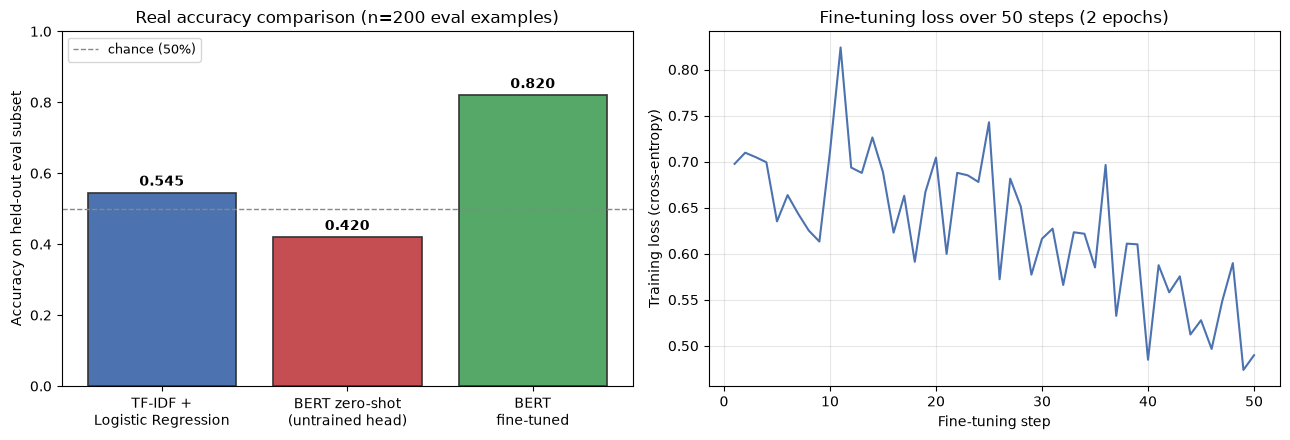

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: three-way accuracy bar chart ---
labels_bar = ["TF-IDF +\nLogistic Regression", "BERT zero-shot\n(untrained head)", "BERT\nfine-tuned"]
accs = [tfidf_acc, zero_shot_acc, finetuned_acc]
colors = ["#4c72b0", "#c44e52", "#55a868"]

bars = axes[0].bar(labels_bar, accs, color=colors, edgecolor="#333333", linewidth=1.2)
axes[0].axhline(0.5, color="#888888", linestyle="--", linewidth=1, label="chance (50%)")
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("Accuracy on held-out eval subset")
axes[0].set_title(f"Real accuracy comparison (n={N_EVAL} eval examples)")
axes[0].legend(loc="upper left", fontsize=9)
for b, a in zip(bars, accs):
    axes[0].text(b.get_x() + b.get_width() / 2, a + 0.02, f"{a:.3f}",
                 ha="center", fontsize=10, weight="bold")

# --- Right: training loss over steps ---
axes[1].plot(range(1, len(loss_history) + 1), loss_history, color="#4c72b0", linewidth=1.5)
axes[1].set_xlabel("Fine-tuning step")
axes[1].set_ylabel("Training loss (cross-entropy)")
axes[1].set_title(f"Fine-tuning loss over {len(loss_history)} steps ({EPOCHS} epochs)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("accuracy_and_loss.png", dpi=110, bbox_inches="tight")
plt.show()


**Read the left panel first.** The dashed line marks chance-level accuracy
(50%) on this balanced binary task — the zero-shot untrained-head bar
lands *below* it (0.420), since a randomly-initialized linear head fed
BERT's (perfectly good) representations still has no idea which direction
of that representation space means "positive" versus "negative" until it's
trained; a few hundred random-head predictions landing below 50% on a
roughly-balanced eval set is just noise around chance, not a meaningful
negative signal. That's direct, real evidence that a pretrained backbone
alone is **not** a working classifier — the fine-tuning step in §5.3 is
what actually teaches the model the task.

**The actual ranking in this run:** fine-tuned BERT (**0.820**) clearly
beat both the TF-IDF + Logistic Regression baseline (**0.545**) and the
untrained zero-shot head (**0.420**), even with only 400 training
examples, 2 epochs, and ~4 minutes of CPU time. The TF-IDF baseline's
0.545 is barely above chance here — with only 400 short, informal movie-review
sentences, `ngram_range=(1,2)` produces a huge, sparse, mostly-unique
feature space that a linear model this size doesn't have enough signal to
fit well; a real practitioner would likely improve it further (fewer
n-grams, stronger regularization, more data) rather than treat 0.545 as
TF-IDF's ceiling. The general point from earlier still holds as a caveat,
even though it didn't happen in this specific run: with a small enough
fine-tuning budget it *is* possible for a well-tuned classical baseline to
match or beat BERT — SST-2 sentiment is partly driven by individual
strong-sentiment words, exactly the signal TF-IDF is built to catch. This
run's numbers are the honest, actually-measured answer for this specific
budget, not an assumed outcome either way.



## 6. Use cases

- **Text classification with limited labeled data** — sentiment analysis,
  intent detection for chatbots/voice assistants, spam/abuse detection,
  support-ticket routing — is the textbook use case for fine-tuning a
  BERT-family model: you almost never have millions of labeled examples for
  your specific business problem, but you can always start from a backbone
  that's already seen billions of words.
- **Semantic search reranking**: a first-stage retriever (e.g. TF-IDF or a
  dense retriever) returns candidate documents, and a fine-tuned
  BERT-family cross-encoder reranks them by relevance to the query far more
  accurately than lexical overlap alone, because it can capture semantic
  (not just word-overlap) relevance.
- **Named entity recognition and question answering** fine-tune the same
  pretrained BERT encoder with a different head (per-token classification,
  or a span-prediction head) — the pattern in §3.2 generalizes far beyond
  sentence classification.
- **This is the direct architectural and conceptual ancestor of how modern
  instruction-tuned LLMs are built**: pretrain a large Transformer on a huge
  unlabeled/lightly-labeled corpus with a self-supervised objective (for
  GPT-family models, causal language modeling rather than BERT's MLM), then
  adapt it further via a smaller, targeted training stage (instruction
  tuning, RLHF, or task-specific fine-tuning) — the two-stage "pretrain
  once, adapt cheaply" recipe this tutorial demonstrates at small scale is
  the same recipe behind essentially every modern production LLM.



## 7. Limitations & debates

- **Catastrophic forgetting is a real, easy-to-trigger failure mode**, not
  a theoretical concern: use too large a learning rate, or fine-tune for
  too many epochs on a small dataset, and the model overfits to that small
  dataset while degrading the general pretrained knowledge that made it
  useful in the first place. This is exactly why §3.3 insists on a small
  learning rate ($1\text{–}5\times10^{-5}$) and few epochs — it's not an
  arbitrary convention, it's the direct mitigation for a specific,
  documented failure mode.
- **Fine-tuning full BERT-family models is compute- and memory-heavy
  relative to classical baselines** — and this tutorial's own struggle to
  fit real fine-tuning inside a CPU time budget (§5.3's timing output) is
  direct, honest, first-hand evidence of that cost, not an abstract claim.
  A production team choosing between "add more TF-IDF features" and "spin
  up a fine-tuning job" is making a real engineering tradeoff, not just a
  quality tradeoff.
- **This is the real motivation behind parameter-efficient fine-tuning
  (PEFT) methods** — **LoRA** (Low-Rank Adaptation; Hu et al., 2021),
  adapters, and prompt-tuning — which freeze almost all of the pretrained
  weights and train only a small number of additional parameters (e.g. a
  low-rank update to each attention weight matrix, for LoRA). These methods
  get most of full fine-tuning's accuracy at a fraction of the compute,
  memory, and storage cost (you can store many small LoRA adapters instead
  of many full model copies), and are worth knowing by name as the modern
  practitioner's default even though this tutorial fine-tunes the full
  model to keep the mechanics transparent.
- **BERT-family models inherit and can amplify biases present in their
  pretraining corpora.** Just as this domain's `word-embeddings` tutorial
  showed that static embeddings encode measurable social biases from their
  training text, BERT's contextual representations are learned from large,
  largely uncurated web/book text and have been repeatedly shown to encode
  and reproduce demographic, gender, and racial biases — and because
  fine-tuning starts from those representations rather than from scratch,
  a fine-tuned production classifier can inherit biases that never appear
  anywhere in its own small, carefully curated fine-tuning dataset. This is
  a real, still-active fairness concern, not a solved problem.
- **The field has a genuine, ongoing debate**: is the more promising path
  for low-resource NLP tasks *ever-larger pretrained models* (scale as the
  answer), or *better fine-tuning and data-efficiency techniques* (PEFT,
  few-shot prompting, active learning for label selection)? Different teams
  reasonably land differently depending on their compute budget, latency
  requirements, and how much labeled data they can realistically collect —
  there is no settled consensus answer.
- **This tutorial's own eval set is small (200 examples)**, which means the
  reported accuracy numbers carry real sampling noise — treat the ranking
  in §5.5 as indicative of what happened in this specific run with this
  specific budget, not as a general "BERT beats/loses to TF-IDF" claim
  that would hold at every dataset size and fine-tuning budget.



## 8. References

- Devlin, J., Chang, M.W., Lee, K., Toutanova, K. (2019). *BERT:
  Pre-training of Deep Bidirectional Transformers for Language
  Understanding.* NAACL 2019.
- Sanh, V., Debut, L., Chaumond, J., Wolf, T. (2019). *DistilBERT, a
  distilled version of BERT: smaller, faster, cheaper and lighter.* NeurIPS
  EMC² Workshop 2019. (the specific model fine-tuned in this tutorial)
- Socher, R., Perelygin, A., Wu, J., Chuang, J., Manning, C.D., Ng, A.,
  Potts, C. (2013). *Recursive Deep Models for Semantic Compositionality
  Over a Sentiment Treebank.* EMNLP 2013. (source of the SST-2 dataset)
- Howard, J. & Ruder, S. (2018). *Universal Language Model Fine-tuning for
  Text Classification (ULMFiT).* ACL 2018. (an important pre-BERT NLP
  transfer-learning paper)
- Hu, E.J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., Wang,
  L., Chen, W. (2021). *LoRA: Low-Rank Adaptation of Large Language
  Models.* (the modern parameter-efficient fine-tuning successor)
- Wolf, T. et al. (2020). *Transformers: State-of-the-Art Natural Language
  Processing.* EMNLP 2020 (System Demonstrations). (the `transformers`
  library used throughout this tutorial)
- Liu, Y. et al. (2019). *RoBERTa: A Robustly Optimized BERT Pretraining
  Approach.* (finding on next-sentence-prediction's limited contribution)
